In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
# CONSTANTS
g0 = 9.8 # m/s2
R = 287 # J/kg/K

def calc_tau():
    zeta = np.random.uniform()
    return - 1 * np.log(1 - zeta)

def scale_height(t_avg):
    return t_avg * R / g0

In [3]:
def monte_carlo_model(theta, tau_star, t_avg, num_photons=10e4):
    mu = np.abs(np.cos(theta).round(15)) # correct for python precision error
    H = scale_height(t_avg = t_avg)
    df = pd.DataFrame(np.ones(int(num_photons))*H,columns=['Z_atm'])
    df['tau'] = df.apply(lambda x: calc_tau(),axis = 1)
    df['tau_star'] = tau_star / mu # given tau star is for theta = 0, need to correct for incidence angle
    df['mu'] = mu
    df['L'] = (df['Z_atm'] / df['mu']) * (df['tau'] / df['tau_star'])
    df['L_atm'] = df['Z_atm'] / df['mu']
    df['reached_sfc'] = df['L'] > df['L_atm']
    return df

## Part 2: Model Verification
To ensure my model is working correctly, I will test the boundary conditions of the inputs. 
1. Incidence angle $\theta$. If the incidence angle is parallel to the surface, no photons will reach the surface as we are not taking into account scattering. The model should return a transmission of zero. I will create a plot of incidence angle vs transmission and expect the transmission to decrease to zero as incidence angle goes from $0$ to $90°$.
2. $\tau^*$. If the total optical depth of the atmosphere is zero, all photons will reach the surface (100%). If the total optical depth is sufficiently high (>8) no photons should reach the surface. To test this I will create a plot of transmission vs optical depth. The plot should show transmission going from 1 to 0 as optical depth increases, reaching zero at an optical depth of at least 8.
    - NOTE: since optical depth theoretically does not have an upper limit this test case does not have as strict of a pass/fail.

/var/folders/ys/qmftlyyx3dj63021dv4205g80000gn/T/ipykernel_33190/3629101829.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  df['tau_star'] = tau_star / mu # given tau star is for theta = 0, need to correct for incidence angle


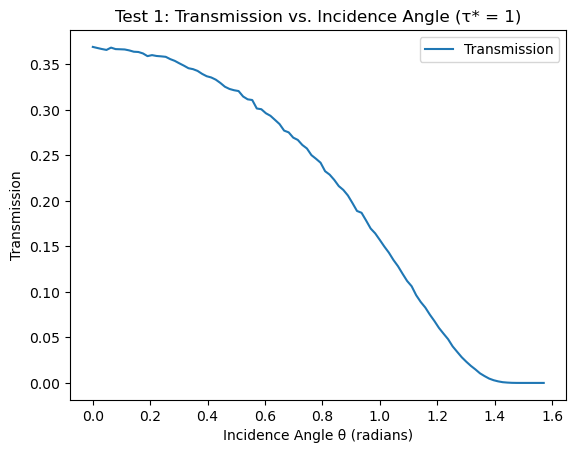

In [4]:
# TEST 1

theta_test = pd.DataFrame(np.linspace(0,np.pi/2,100),columns=['theta_vals'])
theta_test['I_0'] = 10e4
theta_test['I_sfc'] = theta_test.apply(lambda x: monte_carlo_model(theta = x['theta_vals'],tau_star = 1,t_avg=290,num_photons=x['I_0'])['reached_sfc'].sum(),axis=1)
theta_test['transmission'] = theta_test['I_sfc']/theta_test['I_0']

fig, ax = plt.subplots()
theta_test.plot(x='theta_vals', y='transmission', ax=ax)
ax.set_xlabel('Incidence Angle θ (radians)')
ax.set_ylabel('Transmission')
ax.set_title('Test 1: Transmission vs. Incidence Angle (τ* = 1)')
ax.legend(['Transmission'])
fig.savefig('figures/test1_transmission_vs_theta.png', dpi=150, bbox_inches='tight')

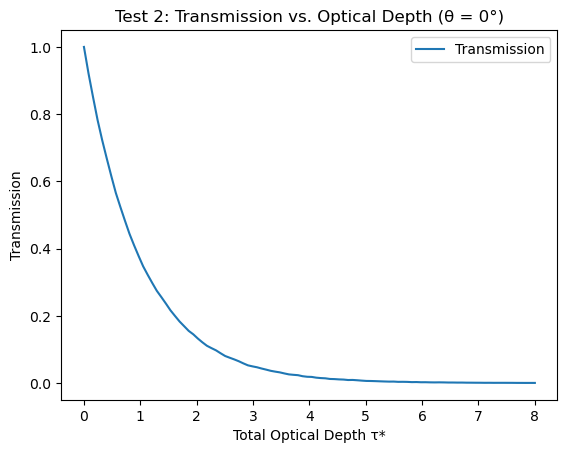

In [5]:
# TEST 2
tau_test = pd.DataFrame(np.linspace(0,8,100),columns=['tau_vals'])
tau_test['I_0'] = 10e4
tau_test['I_sfc'] = tau_test.apply(lambda x: monte_carlo_model(theta = 0,tau_star = x['tau_vals'],t_avg=290,num_photons=x['I_0'])['reached_sfc'].sum(),axis=1)
tau_test['transmission'] = tau_test['I_sfc']/tau_test['I_0']

fig, ax = plt.subplots()
tau_test.plot(x='tau_vals', y='transmission', ax=ax)
ax.set_xlabel('Total Optical Depth τ*')
ax.set_ylabel('Transmission')
ax.set_title('Test 2: Transmission vs. Optical Depth (θ = 0°)')
ax.legend(['Transmission'])
fig.savefig('figures/test2_transmission_vs_tau.png', dpi=150, bbox_inches='tight')

### Test case results
1. Model behaves as expected, no photons reach the surface when the incidence angle is $90°$ ($\pi/2$).
2. For a total optical depth of 0 all photons reach the surface (as expected). For optical depths >5 the transmission is approximately 0. This is the expected behavior of the model since there is not a strict upper bound to optical depth. 

## Part 3: Radiative Transfer Experiments
### Question 1
Based on the equation for intensity, $I(z) = I_0 \exp[-\tau(z)/\mu]$, when $\mu = 1$, we will get an e-folding reduction in initial intensity when $\tau(z) = 1$. If we use the number of photons entering the atmosphere as a proxy for intensity then we should have an e-folding reduction when the percent of photons reaching the surface is $100/e \approx 36.8\%$. When I input $\tau^* = 1$ into my model, I get 36.891% of photons reaching the surface which is very close to the expected value. 

In [6]:
# 1. value of tau with e-folding intensity reduction
theta = 0
df = monte_carlo_model(theta = theta, tau_star = 1, t_avg = 290, num_photons=10e4)
print(f"e-folding reduction:                                {100/np.e}")
print(f"Percent of photons reaching the sfc with tau = 1:   {df['reached_sfc'].sum()*100 / len(df)}%")


e-folding reduction:                                36.787944117144235
Percent of photons reaching the sfc with tau = 1:   36.638%


### Question 2
Transmittance can be calculated using the equation $\exp[-\tau/\mu]$. Using this relationship, the transmittance at an incidence angle of $60°$ and $\tau = 1$ should be $\approx 0.135$. I can verify this relationship using my model, which outputs 0.1376, which is very similar to the expected result. 

In [7]:
# 2. surface transmittance when theta = 60
df = monte_carlo_model(theta = np.pi/3, tau_star = 1, t_avg = 290, num_photons=10e4)
print(f"Expected transmittance for theta = pi/3 and tau = 1:    {np.exp(-1/np.cos(np.pi/3))}")
print(f"Model transmittance for theta = pi/3 and tau = 1:       {df['reached_sfc'].sum()/len(df)}")


Expected transmittance for theta = pi/3 and tau = 1:    0.13533528323661276
Model transmittance for theta = pi/3 and tau = 1:       0.13526


### Question 3
In a purely absorbing atmosphere, the surface would be dark when the sun is at the horizon (assuming a point source) because the photons from the sun would be traveling parallel to the surface and therefore never make contact with the surface. The photon would either be absorbed at some point in the atmosphere (which is much longer than at the zenith angle) or it would pass completely through the atmosphere without hitting the surface. This can be shown using the model by setting the incident angle to $\pi/2$. No matter what the other input parameters are (even $\tau^* = 0$), the percent of photons that hit the surface is zero (as demonstrated in the test case).

In [8]:
df = monte_carlo_model(theta = np.pi/2, tau_star = 0, t_avg = 290, num_photons=10e4)
print(f"Percent of photons reaching the sfc: {df['reached_sfc'].sum()*100 / len(df)}%")

Percent of photons reaching the sfc: 0.0%


/var/folders/ys/qmftlyyx3dj63021dv4205g80000gn/T/ipykernel_33190/3629101829.py:6: RuntimeWarning: invalid value encountered in scalar divide
  df['tau_star'] = tau_star / mu # given tau star is for theta = 0, need to correct for incidence angle


### Question 4

For each $\tau$ value, transmission decreases exponentially with height. But the rate of decrease increases with $\tau$. For $\tau = 1$, transmission decreases approximately linearly with depth, but by $\tau = 10$, transmission drops off to zero halfway through the atmosphere. 

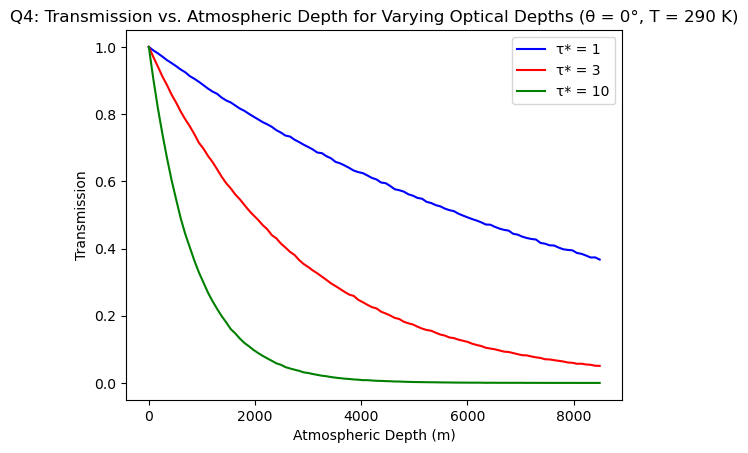

In [9]:
# for each depth of atmosphere, count how many photons reached
atm_depth_df = pd.DataFrame(np.linspace(0,scale_height(290),100),columns=['atm_depth'])
atm_depth_df['I_0'] = 10e4

atm_depth_df['I_1'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 1,t_avg=290,num_photons=x['I_0'])['L'] > x['atm_depth']).sum(),axis=1)
atm_depth_df['I_3'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 3,t_avg=290,num_photons=x['I_0'])['L'] > x['atm_depth']).sum(),axis=1)
atm_depth_df['I_10'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 10,t_avg=290,num_photons=x['I_0'])['L'] > x['atm_depth']).sum(),axis=1)

fig, ax = plt.subplots()
ax.plot(atm_depth_df['atm_depth'],atm_depth_df['I_1']/atm_depth_df['I_0'],color='b',label='τ* = 1')
ax.plot(atm_depth_df['atm_depth'],atm_depth_df['I_3']/atm_depth_df['I_0'],color='r',label='τ* = 3')
ax.plot(atm_depth_df['atm_depth'],atm_depth_df['I_10']/atm_depth_df['I_0'],color='g',label='τ* = 10')
ax.set_xlabel('Atmospheric Depth (m)')
ax.set_ylabel('Transmission')
ax.set_title('Q4: Transmission vs. Atmospheric Depth for Varying Optical Depths (θ = 0°, T = 290 K)')
ax.legend()
fig.savefig('figures/q4_transmission_vs_depth.png', dpi=150, bbox_inches='tight')

## Part 4: AERONET Observations
- Region: New York City
- Station: CCNY
- Date: 6/7/2023
- [data link](https://aeronet.gsfc.nasa.gov/cgi-bin/data_display_aod_v3?site=CCNY&nachal=0&year=2023&month=6&day=7&aero_water=0&level=1&if_day=0&if_err=0&place_code=10&year_or_month=0)

On this day smoke from Canadian wildfires made it all the way down to New York City, turning the sky orange. This photo was taken in the afternoon  outside my office building.

In [10]:
from IPython.display import Image
Image(url="figures/IMG_5895.JPG", width=300)

In [11]:
df = pd.read_csv("data/20230607_20230607_CCNY.lev20",header = 6)[['Date(dd:mm:yyyy)','Time(hh:mm:ss)','AOD_500nm','Solar_Zenith_Angle(Degrees)']]
df['datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')
df = df.drop(columns=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)'])
df.loc[df['AOD_500nm'] < 0,'AOD_500nm'] = np.nan

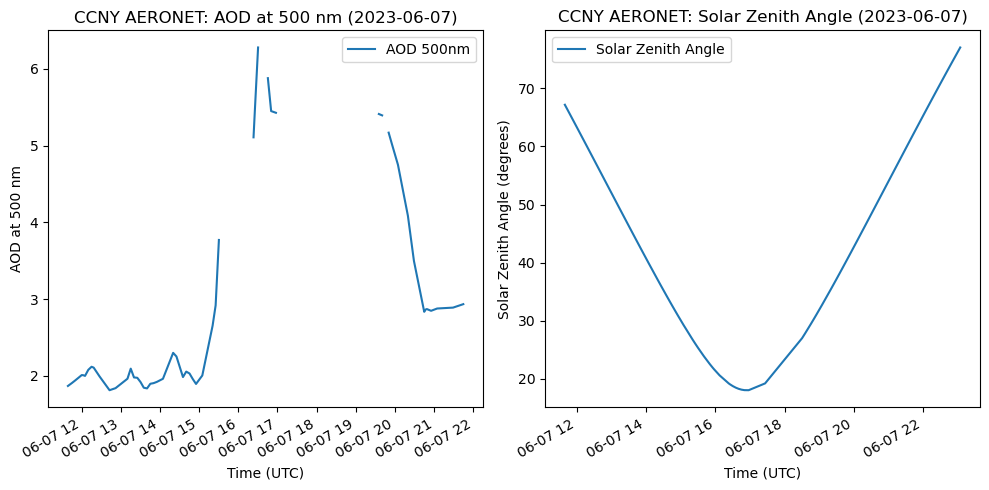

In [12]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
df.plot(x='datetime', y='AOD_500nm', ax=ax[0])
ax[0].set_xlabel('Time (UTC)')
ax[0].set_ylabel('AOD at 500 nm')
ax[0].set_title('CCNY AERONET: AOD at 500 nm (2023-06-07)')
ax[0].legend(['AOD 500nm'])

df.plot(x='datetime', y='Solar_Zenith_Angle(Degrees)', ax=ax[1])
ax[1].set_xlabel('Time (UTC)')
ax[1].set_ylabel('Solar Zenith Angle (degrees)')
ax[1].set_title('CCNY AERONET: Solar Zenith Angle (2023-06-07)')
ax[1].legend(['Solar Zenith Angle'])

fig.tight_layout()
fig.savefig('figures/aeronet_aod_and_sza.png', dpi=150, bbox_inches='tight')

### Question 5
- The primary source of aerosols at this station on this day is the smoke from the wildfires.
- The direct transmittance at the surface decreases dramatically throughout the day. The AOD starts at around 2 at noon (minimum value of 1.8 at 12:45pm). At this point in the day the solar zenith angle is high which will decrease the transmission of solar radiation to the surface. For the measured values of AOD = 1.8 and $\theta = 55°$ at 12:45pm, the transmission was 0.16404. An AOD of 2 is already elevated, but it rises sharply at 3pm to above 6. This is around the time of the minimum solar zenith angle (sun at the maximum point in the sky), meaning on a clear day transmission to the surface would be a maximum. But using $\theta = 19°$ and AOD = 6.3, I calculated the transmission to be 0.00185, which is much lower than the transmission of 0.16404 earlier in the day.
- For a constant $\tau$, the direct surface transmission peaks around 5pm. This follows directly with solar zenith angle, which is a minimum around 5pm. 
- For a constant solar zenith angle, surface transmission drops to zero when optical depth starts to increase (>2). 
- For this case, the transmission is dominated by the optical depth. Just using the daily average optical depth, the peak transmission would only be 0.05. But at this time the optical depth was also maximum, meaning direct solar transmission was approximately zero for the entire day. 

In [13]:
max_aod = df.iloc[df['AOD_500nm'].idxmax()]
min_aod = df.iloc[df['AOD_500nm'].idxmin()]

model_max = monte_carlo_model(theta = np.deg2rad(max_aod['Solar_Zenith_Angle(Degrees)']),tau_star = max_aod['AOD_500nm'],t_avg=290,num_photons=10e4)
model_min = monte_carlo_model(theta = np.deg2rad(min_aod['Solar_Zenith_Angle(Degrees)']),tau_star = min_aod['AOD_500nm'],t_avg=290,num_photons=10e4)

print(f"Transmittance at {min_aod['datetime']}: {model_min['reached_sfc'].sum()/len(model_min)}")
print(f"Transmittance at {max_aod['datetime']}: {model_max['reached_sfc'].sum()/len(model_max)}")

Transmittance at 2023-06-07 12:42:52: 0.04211
Transmittance at 2023-06-07 16:30:21: 0.00119


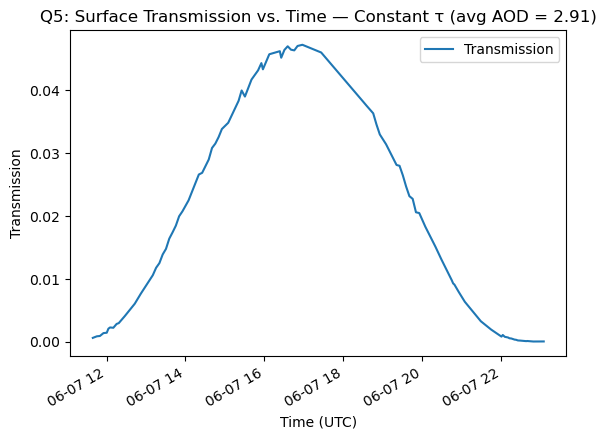

In [14]:
# constant tau (avg AOD)
# this mean is likely biased low as there are many missing data points during the peak AOD

df_const_AOD = df[['Solar_Zenith_Angle(Degrees)','datetime']]
df_const_AOD['tau_avg'] = df['AOD_500nm'].mean()
df_const_AOD['I_0'] = 10e4

df_const_AOD['I_sfc'] = df_const_AOD.apply(lambda x: monte_carlo_model(theta = np.deg2rad(x['Solar_Zenith_Angle(Degrees)']),tau_star = x['tau_avg'],t_avg=290,num_photons=x['I_0'])['reached_sfc'].sum(),axis=1)
df_const_AOD['transmission'] = df_const_AOD['I_sfc']/df_const_AOD['I_0']

fig, ax = plt.subplots()
df_const_AOD.plot(x='datetime', y='transmission', ax=ax)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Transmission')
ax.set_title(f'Q5: Surface Transmission vs. Time — Constant τ (avg AOD = {df["AOD_500nm"].mean():.2f})')
ax.legend(['Transmission'])
fig.savefig('figures/q5_transmission_const_tau.png', dpi=150, bbox_inches='tight')

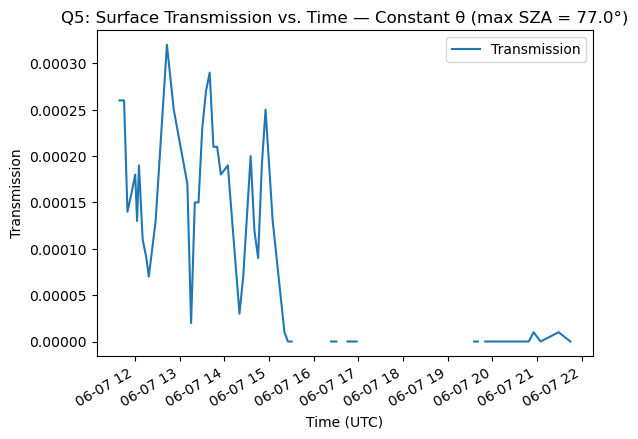

In [15]:
# constant theta (theta max)
df_const_theta = df[['AOD_500nm','datetime']]
df_const_theta['theta_max'] = df['Solar_Zenith_Angle(Degrees)'].max()
df_const_theta['I_0'] = 10e4

df_const_theta['I_sfc'] = df_const_theta.apply(lambda x: monte_carlo_model(theta = np.deg2rad(x['theta_max']),tau_star = x['AOD_500nm'],t_avg=290,num_photons=x['I_0'])['reached_sfc'].sum(),axis=1)
df_const_theta['transmission'] = df_const_theta['I_sfc']/df_const_theta['I_0']

df_const_theta.loc[df_const_theta['AOD_500nm'].isna(),'transmission'] = np.nan

fig, ax = plt.subplots()
df_const_theta.plot(x='datetime', y='transmission', ax=ax)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Transmission')
ax.set_title(f'Q5: Surface Transmission vs. Time — Constant θ (max SZA = {df["Solar_Zenith_Angle(Degrees)"].max():.1f}°)')
ax.legend(['Transmission'])
fig.savefig('figures/q5_transmission_const_theta.png', dpi=150, bbox_inches='tight')

## Part 5: Student Investigation
Question: 
- How does surface transmission change with average planetary temperature (scale height)?

Hypothesis: 
- Surface transmission will increase for colder average planetary temperatures since the photons will have a shorter distance to travel through the atmosphere.

Experiment: 
- Vary average surface temperature from 1 to 500 K holding $\tau$ and $\theta$ constant ($\tau = 1$ and $\theta = 0$ respectively). Plot the results for total surface transmission as a function of surface temperature. 
- Calculate transmission as a function of normalized atmospheric depth (similar to part 3 question 4) for 5 representative temperatures. 

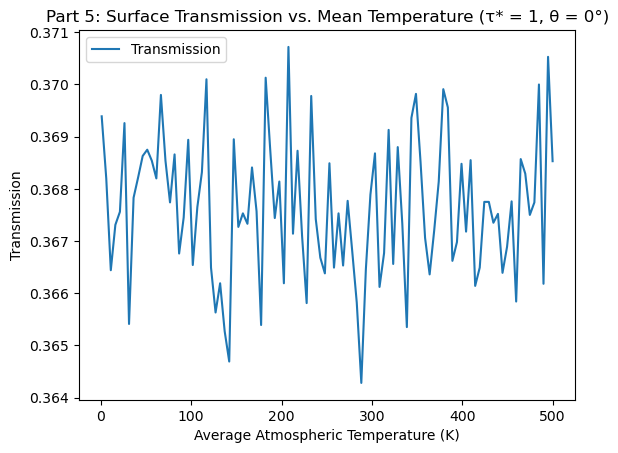

In [16]:
tavg_test = pd.DataFrame(np.linspace(1,500,100),columns=['tavg'])
tavg_test['I_0'] = 10e4
tavg_test['I_sfc'] = tavg_test.apply(lambda x: monte_carlo_model(theta = 0,tau_star = 1,t_avg=x['tavg'],num_photons=x['I_0'])['reached_sfc'].sum(),axis=1)
tavg_test['transmission'] = tavg_test['I_sfc']/tavg_test['I_0']

fig, ax = plt.subplots()
tavg_test.plot(x='tavg', y='transmission', ax=ax)
ax.set_xlabel('Average Atmospheric Temperature (K)')
ax.set_ylabel('Transmission')
ax.set_title('Part 5: Surface Transmission vs. Mean Temperature (τ* = 1, θ = 0°)')
ax.legend(['Transmission'])
fig.savefig('figures/part5_transmission_vs_temperature.png', dpi=150, bbox_inches='tight')

In [17]:
# for each depth of atmosphere, count how many photons reached
atm_depth_df = pd.DataFrame(np.linspace(0,1,100),columns=['atm_depth_norm'])
atm_depth = scale_height(np.array([100,200,300,400,500]))
atm_depth_df['I_0'] = 10e4

atm_depth_df['I_100'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 1,t_avg=100,num_photons=x['I_0'])['L'] > x['atm_depth_norm']*atm_depth[0]).sum(),axis=1)
atm_depth_df['I_200'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 1,t_avg=200,num_photons=x['I_0'])['L'] > x['atm_depth_norm']*atm_depth[1]).sum(),axis=1)
atm_depth_df['I_300'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 1,t_avg=300,num_photons=x['I_0'])['L'] > x['atm_depth_norm']*atm_depth[2]).sum(),axis=1)
atm_depth_df['I_400'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 1,t_avg=400,num_photons=x['I_0'])['L'] > x['atm_depth_norm']*atm_depth[3]).sum(),axis=1)
atm_depth_df['I_500'] = atm_depth_df.apply(lambda x: (monte_carlo_model(theta = 0,tau_star = 1,t_avg=500,num_photons=x['I_0'])['L'] > x['atm_depth_norm']*atm_depth[4]).sum(),axis=1)

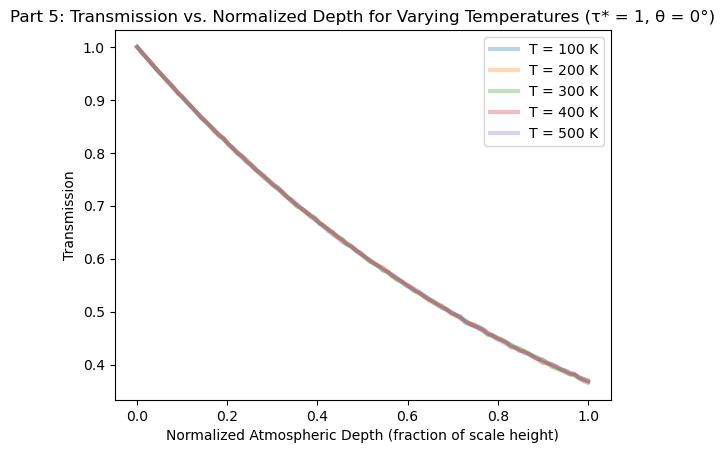

In [18]:
fig, ax = plt.subplots()
ax.plot(atm_depth_df['atm_depth_norm'],atm_depth_df['I_100']/atm_depth_df['I_0'],label='T = 100 K',linewidth = 3, alpha = 0.3)
ax.plot(atm_depth_df['atm_depth_norm'],atm_depth_df['I_200']/atm_depth_df['I_0'],label='T = 200 K',linewidth = 3, alpha = 0.3)
ax.plot(atm_depth_df['atm_depth_norm'],atm_depth_df['I_300']/atm_depth_df['I_0'],label='T = 300 K',linewidth = 3, alpha = 0.3)
ax.plot(atm_depth_df['atm_depth_norm'],atm_depth_df['I_400']/atm_depth_df['I_0'],label='T = 400 K',linewidth = 3, alpha = 0.3)
ax.plot(atm_depth_df['atm_depth_norm'],atm_depth_df['I_500']/atm_depth_df['I_0'],label='T = 500 K',linewidth = 3, alpha = 0.3)

ax.set_xlabel('Normalized Atmospheric Depth (fraction of scale height)')
ax.set_ylabel('Transmission')
ax.set_title('Part 5: Transmission vs. Normalized Depth for Varying Temperatures (τ* = 1, θ = 0°)')
ax.legend()
fig.savefig('figures/part5_transmission_vs_norm_depth.png', dpi=150, bbox_inches='tight')

### Results
Atmospheric transmission is independent of surface temperature/scale height. The results of my experiment proved my hypothesis to be false. The surface transmission has no dependence on surface temperature. The variability in the plot represents the uniform distribution of $\tau$, but there is no discernible trend between these two variables. For any surface temperature, at $\theta = 0$ and $\tau^* = 1$ surface transmission will be on average 0.368. When looking at transmission as a function of atmospheric depth, we can again see that there is no dependence on surface temperature. The surface temperature lines are plotted on top of one another, proving that atmospheric transmission is not a function of atmospheric depth, and only depends on $\tau$ and $\theta$ (in this simple model). In this plot the atmospheric depth is normalized for even comparison between surface temperatures. 

# AI Usage
Tool:
- Claude Code

Prompts:
- convert the date and time columns into one datetime object column
- in monte_carlo_1.ipynb, update the code for each plot to have proper axis labels and titles and save all figures to the figures folder
- based on the assignment document SIOC_251_Homework_1.pdf verify that I answered all parts of the assignment
- check all markdown cells for spelling and grammar. Only modify errors for correcness.
- update the repo README.md to include all new files from homework 0 and 1
- update formulas and special characters in the markdown cells of monte_carlo_1.ipynb